**Predicting Loan Approval Decisions Using Machine Learning Classification Models**

- Overview

This project focuses on predicting loan approval status using machine learning techniques. The dataset contains applicant demographic, financial, employment, and credit-related information that can help determine whether a loan application is likely to be approved.

The objective is to build an intelligent classification model capable of assisting financial institutions in making faster, more consistent, and data-driven lending decisions.

In [69]:
# %pip install -q -U kagglehub

#### **Requirement Gathering, Data Source**

In [70]:
import os
import kagglehub
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings


warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
sns.set_style("whitegrid")

%matplotlib inline

def show_layout():
    plt.figure(figsize=(9, 4))
    plt.tight_layout()
    plt.show()

In [71]:
# Download latest version
path = kagglehub.dataset_download("muhammadmusharraf444/loan-approval-dataset")
source_path = path
destination_path = os.getcwd()

# Copy dataset from source directory to destination directory
source_path = path
destination_path = os.getcwd()

shutil.copytree(source_path, destination_path, dirs_exist_ok = True)

'c:\\Users\\AYO_AYO\\Desktop\\Machine-Learning-Bootcamp'

In [72]:
source_path

'C:\\Users\\AYO_AYO\\.cache\\kagglehub\\datasets\\muhammadmusharraf444\\loan-approval-dataset\\versions\\1'

In [73]:
loan_df = pd.read_csv("./loan_data_new.csv")
loan_df.head()

,Age,Gender,Education,Person Income,Employee Experience,Home Onwership,Loan Amount,Loan Intent,Loan interest Rate,Loan percentage,Credit History,Credit Score,Previous Loan,Loan Status
0,22,female,Master,71948,0,RENT,35000,PERSONAL,16.02,0.49,3,561,No,1
1,21,female,High School,12282,0,OWN,1000,EDUCATION,11.14,0.08,2,504,Yes,0
2,25,female,High School,12438,3,MORTGAGE,5500,MEDICAL,12.87,0.44,3,635,No,1
3,23,female,Bachelor,79753,0,RENT,35000,MEDICAL,15.23,0.44,2,675,No,1
4,24,male,Master,66135,1,RENT,35000,MEDICAL,14.27,0.53,4,586,No,1


#### **Dataset Overview**

In [74]:
print(f"Rows: {loan_df.shape[0]}, Columns: {loan_df.shape[1]}")
print(loan_df.columns.to_list())
print(loan_df.isna().sum())
print(loan_df.info())

Rows: 45000, Columns: 14
['Age', 'Gender', 'Education', 'Person Income', 'Employee Experience', 'Home Onwership', 'Loan Amount', 'Loan Intent', 'Loan interest Rate', 'Loan percentage', 'Credit History', 'Credit Score', 'Previous Loan', 'Loan Status']
Age                    0
Gender                 0
Education              0
Person Income          0
Employee Experience    0
Home Onwership         0
Loan Amount            0
Loan Intent            0
Loan interest Rate     0
Loan percentage        0
Credit History         0
Credit Score           0
Previous Loan          0
Loan Status            0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  45000 non-null  int64  
 1   Gender               45000 non-null  object 
 2   Education            45000 non-null  object 
 3   Person Income        4

In [75]:
print(f"{loan_df.duplicated().sum()} duplicate/s was found in this dataset")

0 duplicate/s was found in this dataset


#### **Cleaning and Standardization**

In [76]:
loan_df.columns = (loan_df.columns.str.strip().str.replace(" ", "_").str.lower())

loan_df = loan_df.rename(columns={"home_onwership": "home_ownership"})

columns_to_lower = ["loan_intent", "home_ownership"]
loan_df[columns_to_lower] = loan_df[columns_to_lower].apply(lambda x: x.str.lower())

In [89]:
# Assuming your target column name is 'loan_status'
# loan_df['loan_status'] = loan_df['loan_status'].map({"Yes": 1, "No": 0})

numerical_cols = loan_df.select_dtypes([np.number]).columns.to_list()
categorical_cols = [col for col in loan_df.columns if col not in numerical_cols]

print(numerical_cols)
print(categorical_cols)

['age', 'person_income', 'employee_experience', 'loan_amount', 'loan_interest_rate', 'loan_percentage', 'credit_history', 'credit_score', 'loan_status']
['gender', 'education', 'home_ownership', 'loan_intent', 'previous_loan']


### **Univariate Analysis**

In [90]:
print("Summary statistics for numerical columns:")
print(loan_df[numerical_cols].describe())
print(loan_df[numerical_cols].isna().sum())

Summary statistics for numerical columns:
                age  person_income  employee_experience   loan_amount  \
count  45000.000000   4.500000e+04         45000.000000  45000.000000   
mean      27.764178   8.031905e+04             5.410333   9583.157556   
std        6.045108   8.042250e+04             6.063532   6314.886691   
min       20.000000   8.000000e+03             0.000000    500.000000   
25%       24.000000   4.720400e+04             1.000000   5000.000000   
50%       26.000000   6.704800e+04             4.000000   8000.000000   
75%       30.000000   9.578925e+04             8.000000  12237.250000   
max      144.000000   7.200766e+06           125.000000  35000.000000   

       loan_interest_rate  loan_percentage  credit_history  credit_score  \
count        45000.000000     45000.000000    45000.000000  45000.000000   
mean            11.006606         0.139725        5.867489    632.608756   
std              2.978808         0.087212        3.879702     50.435865

In [96]:
numerical_summary = loan_df[numerical_cols].agg(["mean", "var", "std"])
numerical_summary

,age,person_income,employee_experience,loan_amount,loan_interest_rate,loan_percentage,credit_history,credit_score,loan_status
mean,27.764178,8.031905e+04,5.410333,9.583158e+03,11.006606,0.139725,5.867489,632.608756,0.222222
var,36.543333,6.467778e+09,36.766421,3.987779e+07,8.873299,0.007606,15.052086,2543.776478,0.172843
std,6.045108,8.042250e+04,6.063532,6.314887e+03,2.978808,0.087212,3.879702,50.435865,0.415744


In [ ]:
print(loan_df[numerical_cols].skew()) # type: ignoreow
print(loan_df[numerical_cols].kurtosis()) # type: ignore

age                     2.548154
person_income          34.137583
employee_experience     2.594917
loan_amount             1.179731
loan_interest_rate      0.213784
loan_percentage         1.034512
credit_history          1.631720
credit_score           -0.610261
loan_status             1.336351
dtype: float64
age                      18.649449
person_income          2398.684769
employee_experience      19.168324
loan_amount               1.351215
loan_interest_rate       -0.420335
loan_percentage           1.082416
credit_history            3.725945
credit_score              0.203022
loan_status              -0.214176
dtype: float64


In [113]:
print(loan_df["age"].value_counts().sort_index(ascending = True))

age
20       17
21     1289
22     4236
23     5254
24     5138
25     4507
26     3659
27     3095
28     2728
29     2455
30     2021
31     1645
32     1403
33     1240
34      980
35      847
36      740
37      666
38      503
39      389
40      349
41      303
42      247
43      215
44      177
45      135
46      114
47      112
48       93
49       59
50       56
51       46
52       42
53       35
54       24
55       24
56       20
57       17
58       20
59        6
60       16
61       12
62        7
63        3
64        7
65       10
66       11
67        1
69        5
70        7
73        3
76        1
78        1
80        1
84        1
94        1
109       1
116       1
123       2
144       3
Name: count, dtype: int64


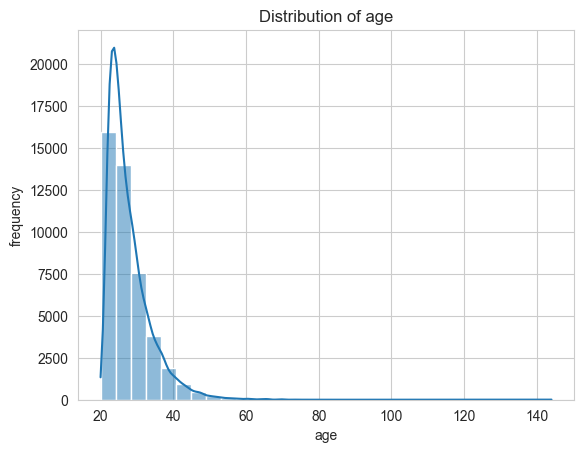

<Figure size 900x400 with 0 Axes>

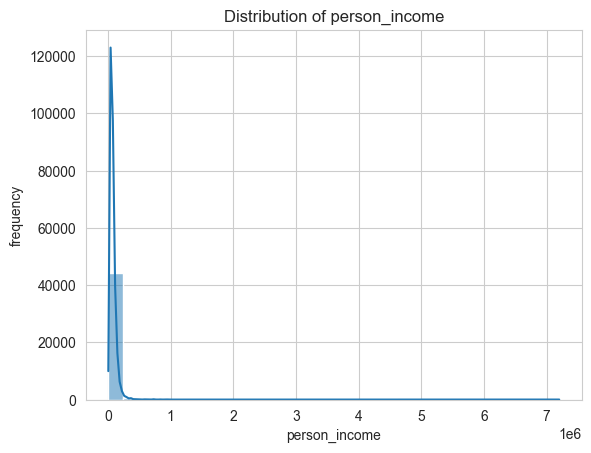

<Figure size 900x400 with 0 Axes>

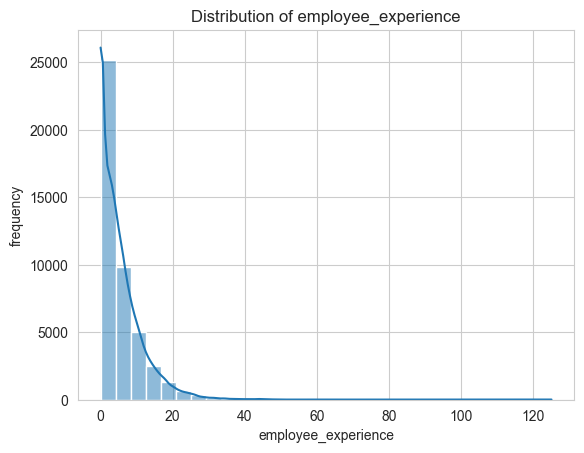

<Figure size 900x400 with 0 Axes>

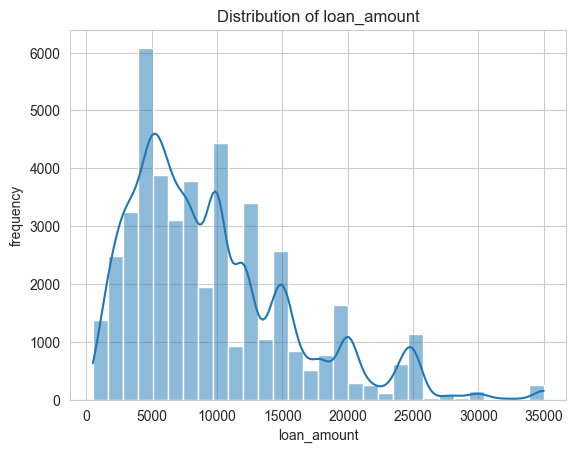

<Figure size 900x400 with 0 Axes>

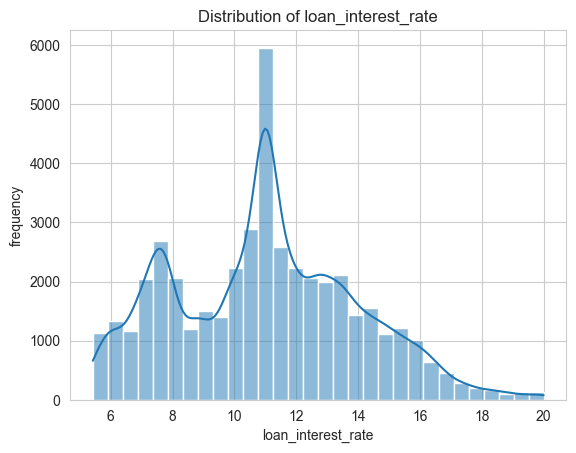

<Figure size 900x400 with 0 Axes>

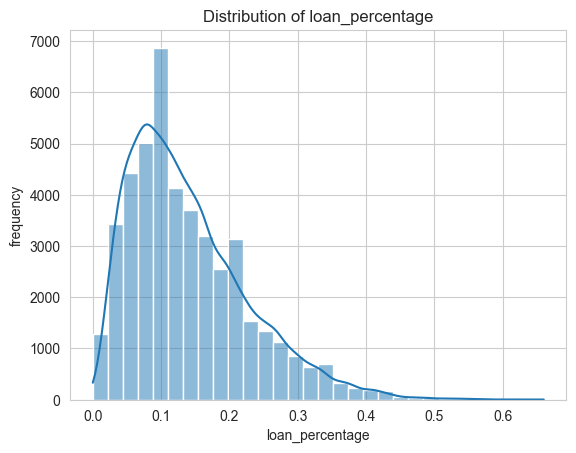

<Figure size 900x400 with 0 Axes>

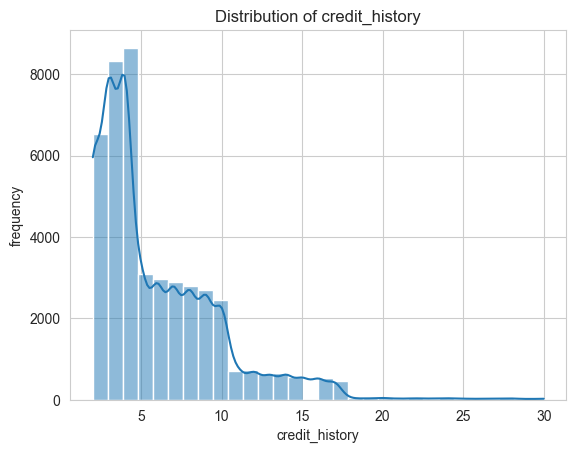

<Figure size 900x400 with 0 Axes>

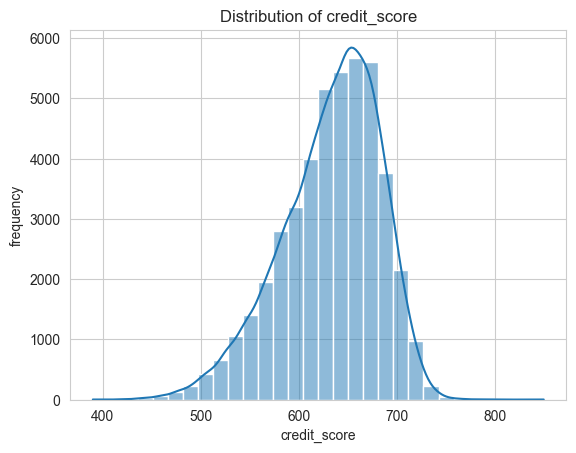

<Figure size 900x400 with 0 Axes>

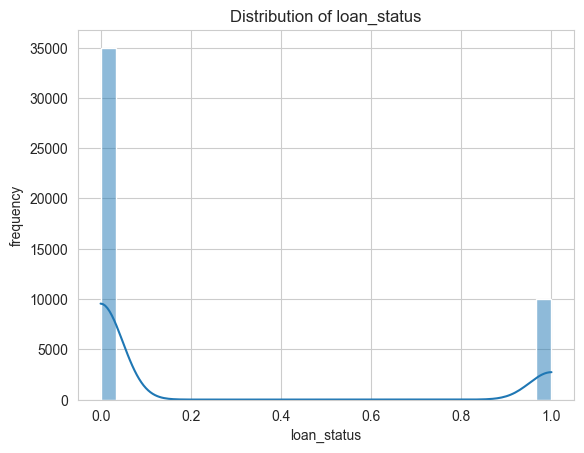

<Figure size 900x400 with 0 Axes>

In [100]:
for cols in numerical_cols:
    sns.histplot(x = loan_df[cols], kde = True, bins = 30)
    plt.title(f"Distribution of {cols}")
    plt.xlabel(cols)
    plt.ylabel("frequency")
    show_layout()

#### **Exploratory Data Analysis**

In [82]:
loan_approved_percentage = round(loan_df['loan_status'].value_counts(normalize=True), 3).mul(100)
print(loan_approved_percentage)

# Highly imbalanced dataset, 78% of loan request were rejected whilst only 22% were accepted, since the model is right 78% of the time, it'll treat others as same (reject)

loan_status
0    77.8
1    22.2
Name: proportion, dtype: float64


In [83]:
loan_df.columns

Index(['age', 'gender', 'education', 'person_income', 'employee_experience',
       'home_ownership', 'loan_amount', 'loan_intent', 'loan_interest_rate',
       'loan_percentage', 'credit_history', 'credit_score', 'previous_loan',
       'loan_status'],
      dtype='object')

In [84]:
salary_threshold = loan_df["person_income"].mean()
print(f"Salary threshold: {round((salary_threshold),2)}")

Salary threshold: 80319.05


In [85]:
# Do applicants with higher incomes get approved more often?

higher_income_group = loan_df[loan_df.loc[:, "person_income"] >= salary_threshold]
lower_income_group = loan_df[loan_df.loc[:, "person_income"] < salary_threshold]

# 2. Extract the exact approval rates
high_income_approval = (higher_income_group["loan_status"] == 1).mean() * 100
low_income_approval = (lower_income_group["loan_status"] == 1).mean() * 100

# Loan approval differences
print(f"High income loan approval rate: {high_income_approval:.2f}%")
print(f"Low income loan approval rate: {low_income_approval:.2f}%")
print(f"Difference in approval rates: {high_income_approval - low_income_approval:.2f}%")

High income loan approval rate: 11.56%
Low income loan approval rate: 28.27%
Difference in approval rates: -16.71%


In [86]:
# Does education level affect approval rates?

education_approval_rate = loan_df.groupby(loan_df["education"])["loan_status"].mean().mul(100).sort_values(ascending=False)
print(education_approval_rate.round(2))

education
Doctorate      22.87
Bachelor       22.52
High School    22.31
Associate      22.03
Master         21.76
Name: loan_status, dtype: float64


In [87]:
# Does employment status influence approval?

self_employment_approval_rate = loan_df.groupby(loan_df.loc[:,"employment"] == "Self-employed")["loan_status"].mean().mul(100).sort_values(ascending=False)
print(round(self_employment_approval_rate, 2))

KeyError: 'employment'

$Visualization$

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings


warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
sns.set_style("whitegrid")

In [ ]:
target_variable = loan_df.iloc[:, -1]

numerical_cols = loan_df.select_dtypes([np.number]).columns.to_list()
categorical_cols = [x for x in loan_df.columns if x not in numerical_cols]

numerical_df = loan_df[numerical_cols]
categorical_df = loan_df[categorical_cols]

**Outlier Detection Using Boxplot**

In [ ]:
for col in numerical_df.columns:
    plt.figure(figsize=(8, 4))
    plt.boxplot(numerical_df[col].dropna())
    plt.title(f"Boxplot - {col}")
    plt.show()

NameError: name 'numerical_df' is not defined

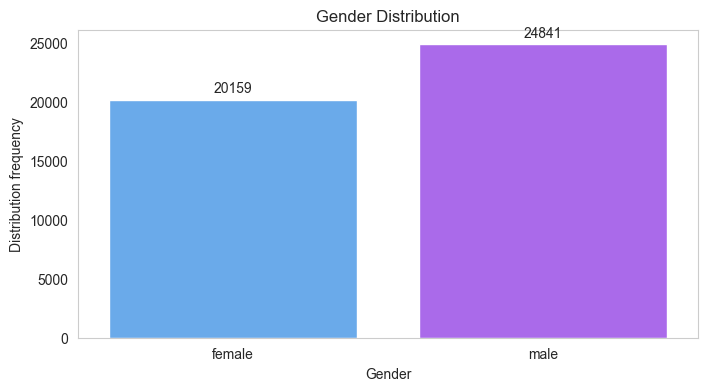

In [ ]:
plt.figure(figsize=(8,4))
ax = sns.countplot(x=loan_df["gender"], palette="cool")

for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)
    
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Distribution frequency")
plt.grid(False)
plt.show()

35000


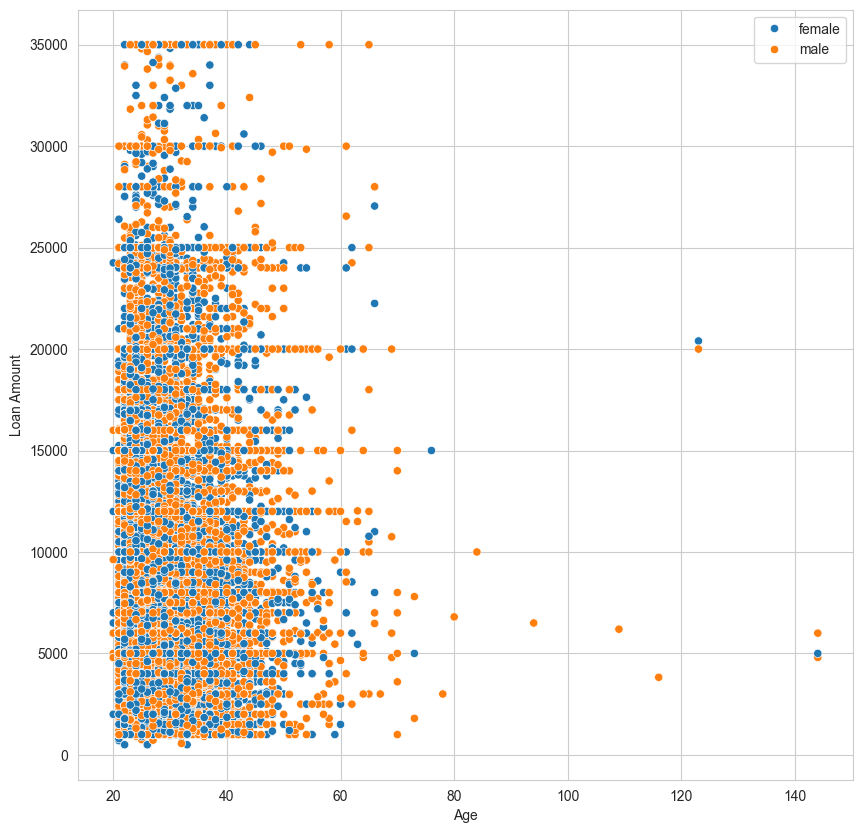

In [ ]:
print(loan_df["loan_amount"].max())

Q1 = loan_df["age"].quantile(.25)
Q3 = loan_df["age"].quantile(.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

normal = loan_df[(loan_df['age'] >= lower_bound) & (loan_df['age'] <= upper_bound)]
outliers = loan_df[(loan_df['age'] < lower_bound) | (loan_df['age'] > upper_bound)]

plt.figure(figsize=(10,10))
sns.scatterplot(x = loan_df["age"], y=loan_df["loan_amount"], hue=loan_df["gender"])
# plt.axvline(upper_bound, color='green', linestyle='--', label='Upper Bound')
# plt.axvline(lower_bound, color='red', linestyle='--', label='Lower Bound')
plt.xlabel("Age")
plt.ylabel("Loan Amount")
plt.legend()
plt.show()